Project: Market Risk Dashboard

Imagine your manager says:

**"Here's a CSV of exchange rates. Tell me if I should be worried."**

*Questions to answer*

What's the latest exchange rate today?

What's the average exchange rate?

What's the worst daily drop?

What's the worst daily increase?

What's the monthly volatility?

Which month was the most volatile?

Plot the exchange rate.

Plot the rolling volatility.

In [2]:
!pip install yfinance 
import pandas as pd 
import matplotlib.pyplot as plt 
import yfinance as yf
import numpy as py
import matplotlib.dates as mdates 

exchange_rate = yf.download('NGN=X', start= '2010-01-01', end= '2024-12-31')
print(exchange_rate.head(10))



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open Volume
Ticker           NGN=X       NGN=X       NGN=X       NGN=X  NGN=X
Date                                                             
2010-01-04  147.539993  149.649994  147.539993  148.550003      0
2010-01-05  149.100006  149.250000  147.440002  149.250000      0
2010-01-06  149.050003  150.300003  146.940002  147.610001      0
2010-01-07  149.000000  149.350006  146.220001  146.220001      0
2010-01-08  149.899994  149.899994  147.300003  147.300003      0
2010-01-11  150.899994  150.899994  148.479996  148.479996      0
2010-01-12  150.399994  150.750000  148.369995  150.500000      0
2010-01-13  151.250000  151.250000  148.500000  150.500000      0
2010-01-14  149.350006  151.259995  149.229996  150.800003      0
2010-01-15  151.100006  151.300003  149.210007  151.300003      0


In [3]:
exchange_rate.isna().sum()

Price   Ticker
Close   NGN=X     0
High    NGN=X     0
Low     NGN=X     0
Open    NGN=X     0
Volume  NGN=X     0
dtype: int64

In [4]:
exchange_rate.head()

Price,Close,High,Low,Open,Volume
Ticker,NGN=X,NGN=X,NGN=X,NGN=X,NGN=X
Date,,,,,
2010-01-04,147.539993,149.649994,147.539993,148.550003,0
2010-01-05,149.100006,149.250000,147.440002,149.250000,0
2010-01-06,149.050003,150.300003,146.940002,147.610001,0
2010-01-07,149.000000,149.350006,146.220001,146.220001,0
2010-01-08,149.899994,149.899994,147.300003,147.300003,0


In [5]:
df_raw = exchange_rate.drop(columns=('Volume', 'NGN=X'))


In [6]:
df_raw.head()


Price,Close,High,Low,Open
Ticker,NGN=X,NGN=X,NGN=X,NGN=X
Date,,,,
2010-01-04,147.539993,149.649994,147.539993,148.550003
2010-01-05,149.100006,149.250000,147.440002,149.250000
2010-01-06,149.050003,150.300003,146.940002,147.610001
2010-01-07,149.000000,149.350006,146.220001,146.220001
2010-01-08,149.899994,149.899994,147.300003,147.300003


In [7]:
exchange_rate_clean = df_raw.droplevel(1, axis= 1)

In [8]:
exchange_rate_clean.head()


Price,Close,High,Low,Open
Date,,,,
2010-01-04,147.539993,149.649994,147.539993,148.550003
2010-01-05,149.100006,149.250000,147.440002,149.250000
2010-01-06,149.050003,150.300003,146.940002,147.610001
2010-01-07,149.000000,149.350006,146.220001,146.220001
2010-01-08,149.899994,149.899994,147.300003,147.300003


In [9]:
exchange_rate_clean.columns

Index(['Close', 'High', 'Low', 'Open'], dtype='str', name='Price')

In [10]:
exchange_rate_clean.columns.name = None

In [11]:
print(exchange_rate_clean)

                  Close         High          Low         Open
Date                                                          
2010-01-04   147.539993   149.649994   147.539993   148.550003
2010-01-05   149.100006   149.250000   147.440002   149.250000
2010-01-06   149.050003   150.300003   146.940002   147.610001
2010-01-07   149.000000   149.350006   146.220001   146.220001
2010-01-08   149.899994   149.899994   147.300003   147.300003
...                 ...          ...          ...          ...
2024-12-24  1548.510010  1548.510010  1541.430054  1548.510010
2024-12-25  1541.430054  1541.430054  1540.660034  1541.430054
2024-12-26  1540.660034  1541.579956  1540.660034  1540.660034
2024-12-27  1541.579956  1552.000000  1541.579956  1541.579956
2024-12-30  1548.270020  1549.199951  1542.790039  1548.500000

[3906 rows x 4 columns]


**Data Cleaning Summary**


Downloaded daily USD/NGN exchange-rate data from Yahoo Finance using yfinance.

Verified the dataset contained no missing values.

Removed the Volume column because it contained only zeros and was not useful for exchange-rate analysis.

Simplified the MultiIndex column headers by removing the ticker level (NGN=X) since only one currency pair was downloaded.

Removed the remaining column Index name (Price) to improve readability.

Retained Date as the index because each observation represents one trading day.


In [12]:
exchange_rate_clean.shape 

(3906, 4)

In [13]:
exchange_rate_clean.head()

,Close,High,Low,Open
Date,,,,
2010-01-04,147.539993,149.649994,147.539993,148.550003
2010-01-05,149.100006,149.250000,147.440002,149.250000
2010-01-06,149.050003,150.300003,146.940002,147.610001
2010-01-07,149.000000,149.350006,146.220001,146.220001
2010-01-08,149.899994,149.899994,147.300003,147.300003


In [14]:
exchange_rate_clean.shape 

(3906, 4)

In [15]:
# What's the latest exchange rate today?
exchange_rate_clean.iloc[-1, 0]

np.float64(1548.27001953125)

In [16]:
# What's the average exchange rate?
exchange_rate_clean['Close'].mean()


np.float64(372.9983769336909)

In [17]:
# What's the worst daily drop?
worst_drop = exchange_rate_clean['Close'].diff()
worst_drop_value = worst_drop.min()
print(worst_drop_value)

worst_drop_date = worst_drop.idxmin()
print(worst_drop_date)


-357.3800001144409
2017-08-08 00:00:00


In [18]:
# What was the largest single-day increase in the USD/NGN exchange rate?

daily_increase = exchange_rate_clean['Close'].diff()
largest_day_value = daily_increase.max()
print(largest_day_value)

largest_day_date = daily_increase.idxmax()
print(largest_day_date)

357.3800001144409
2017-08-09 00:00:00


In [19]:
# What month was the most volatile 

monthly_volatility = exchange_rate_clean['Close'].resample("ME").std()

most_volatile_value = monthly_volatility.max()
most_volatile_month = monthly_volatility.idxmax()
print(f'The most volatile month is {most_volatile_month} with {most_volatile_value:.2f}')

The most volatile month is 2023-06-30 00:00:00 with 151.93


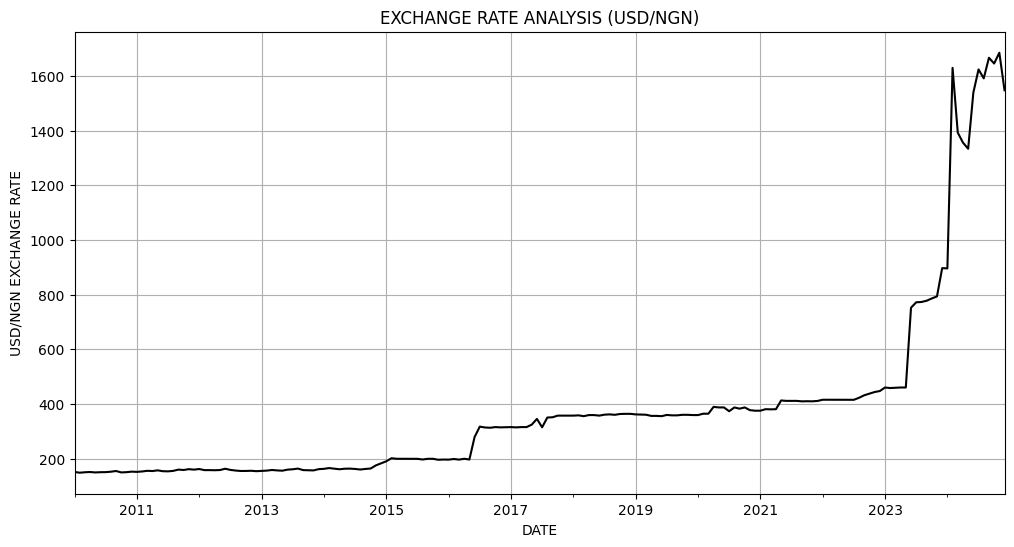

In [20]:
monthly_close = exchange_rate_clean['Close'].resample('ME').last()

monthly_close.plot(figsize=(12, 6), color='black')

plt.title('EXCHANGE RATE ANALYSIS (USD/NGN)')
plt.xlabel('DATE')
plt.ylabel('USD/NGN EXCHANGE RATE')
plt.grid()

plt.show()

**Okay so what i noticed is that the exchange rate was stable and below 200 naira from 2010 to 2014 and had a slight increass from below 200 to 200 towards the end of 2014 and the start of 2015, it was stable till 2016 where it increased to approximately 260 and was consistent with slight increase till 2023 where it was at about 410 and then it plateaued to almost 800 and from that year it incresed drastically to over 1600 naira but as at mid 2023 it reduced from 1600 to about 1350 but in less time it increased back and has been unstable till then.**


**so my observation past years there was some sort of stability but with what the recent data is looking like theres a lot of flauctuation going on so naira is unstable**

In [21]:
yearly_volatility = exchange_rate_clean['Close'].resample('YE').std()
print(yearly_volatility)

Date
2010-12-31      2.171824
2011-12-31     16.809585
2012-12-31      2.161290
2013-12-31      2.019287
2014-12-31      6.121662
2015-12-31     12.836723
2016-12-31     63.596241
2017-12-31     36.253614
2018-12-31     22.184588
2019-12-31      7.640727
2020-12-31     10.476250
2021-12-31     15.416121
2022-12-31     11.119017
2023-12-31    164.921672
2024-12-31    217.705702
Freq: YE-DEC, Name: Close, dtype: float64


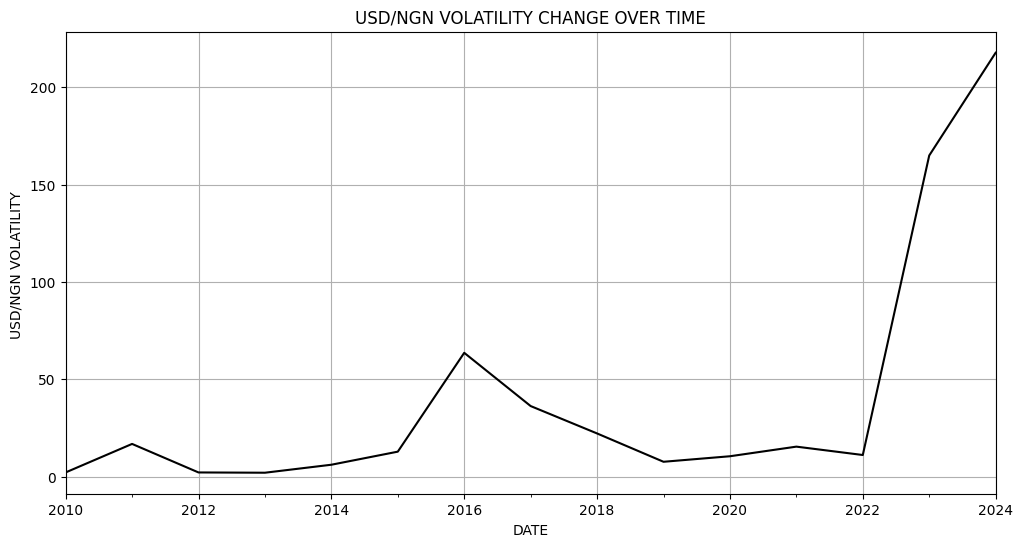

In [22]:
yearly_volatility.plot(figsize=(12, 6), color='black')

plt.title('USD/NGN VOLATILITY CHANGE OVER TIME')
plt.xlabel('DATE')
plt.ylabel('USD/NGN VOLATILITY ')
plt.grid()

plt.show()



**The naira has experienced periods of elevated exchange-rate volatility before, notably in 2016. However, volatility subsequently declined. In contrast, the sharp rise in 2023 continued into 2024, with volatility increasing further rather than returning to earlier levels.**

In [23]:
# Largest percentage change 
daily_pct_change = exchange_rate_clean['Close'].pct_change()

largest_pct_value = daily_pct_change.max()
largest_pct_date = daily_pct_change.idxmax()
print(f'The largest percentage change was {largest_day_date} with the value {largest_day_value:.2f}')

The largest percentage change was 2017-08-09 00:00:00 with the value 357.38


In [24]:
# Worst daily pct change 

worst_pct_value = daily_pct_change.min()
worst_pct_date = daily_pct_change.idxmin()
print(f'The worst percentage change was {worst_pct_date} and the value is {worst_pct_value:.2f}')

The worst percentage change was 2015-07-29 00:00:00 and the value is -0.99


# Phase 2 
**The Impact of Crude Oil Price Volatility on the USD/NGN Exchange rate**

In [25]:
brent_oil = yf.download('BZ=F', start= '2010-01-01', end='2024-12-31')
print(brent_oil.head(10))

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open Volume
Ticker           BZ=F       BZ=F       BZ=F       BZ=F   BZ=F
Date                                                         
2010-01-04  80.120003  79.820000  80.120003  80.120003     97
2010-01-05  80.589996  80.260002  80.589996  80.589996     97
2010-01-06  81.889999  81.699997  80.129997  81.129997      7
2010-01-07  81.510002  81.510002  81.629997  81.510002      7
2010-01-08  81.370003  81.529999  81.089996  81.370003      7
2010-01-11  80.970001  81.709999  81.010002  80.970001      7
2010-01-12  79.300003  79.300003  79.029999  79.300003      7
2010-01-13  78.309998  79.019997  77.250000  78.529999     18
2010-01-14  77.820000  78.470001  78.010002  77.820000      6
2010-01-15  77.110001  77.820000  76.879997  77.550003      4


In [26]:
brent_oil_clean = brent_oil.droplevel(1, axis=1)
print(brent_oil_clean)

Price           Close       High        Low       Open  Volume
Date                                                          
2010-01-04  80.120003  79.820000  80.120003  80.120003      97
2010-01-05  80.589996  80.260002  80.589996  80.589996      97
2010-01-06  81.889999  81.699997  80.129997  81.129997       7
2010-01-07  81.510002  81.510002  81.629997  81.510002       7
2010-01-08  81.370003  81.529999  81.089996  81.370003       7
...               ...        ...        ...        ...     ...
2024-12-23  72.629997  73.370003  71.980003  72.830002   20997
2024-12-24  73.580002  73.809998  72.779999  72.839996    8922
2024-12-26  73.260002  74.180000  72.980003  73.779999    5773
2024-12-27  74.169998  74.339996  73.070000  73.139999    5515
2024-12-30  74.389999  75.040001  73.760002  74.230003   30436

[3740 rows x 5 columns]


In [27]:
brent_oil_clean.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [28]:
brent_oil_clean.columns.name = None
print(brent_oil_clean)

                Close       High        Low       Open  Volume
Date                                                          
2010-01-04  80.120003  79.820000  80.120003  80.120003      97
2010-01-05  80.589996  80.260002  80.589996  80.589996      97
2010-01-06  81.889999  81.699997  80.129997  81.129997       7
2010-01-07  81.510002  81.510002  81.629997  81.510002       7
2010-01-08  81.370003  81.529999  81.089996  81.370003       7
...               ...        ...        ...        ...     ...
2024-12-23  72.629997  73.370003  71.980003  72.830002   20997
2024-12-24  73.580002  73.809998  72.779999  72.839996    8922
2024-12-26  73.260002  74.180000  72.980003  73.779999    5773
2024-12-27  74.169998  74.339996  73.070000  73.139999    5515
2024-12-30  74.389999  75.040001  73.760002  74.230003   30436

[3740 rows x 5 columns]


In [29]:
merged_data = exchange_rate_clean.merge(brent_oil_clean, left_index= True, right_index= True)
print(merged_data.head())

               Close_x      High_x       Low_x      Open_x    Close_y  \
Date                                                                    
2010-01-04  147.539993  149.649994  147.539993  148.550003  80.120003   
2010-01-05  149.100006  149.250000  147.440002  149.250000  80.589996   
2010-01-06  149.050003  150.300003  146.940002  147.610001  81.889999   
2010-01-07  149.000000  149.350006  146.220001  146.220001  81.510002   
2010-01-08  149.899994  149.899994  147.300003  147.300003  81.370003   

               High_y      Low_y     Open_y  Volume  
Date                                                 
2010-01-04  79.820000  80.120003  80.120003      97  
2010-01-05  80.260002  80.589996  80.589996      97  
2010-01-06  81.699997  80.129997  81.129997       7  
2010-01-07  81.510002  81.629997  81.510002       7  
2010-01-08  81.529999  81.089996  81.370003       7  


In [30]:
merged_data = merged_data.rename(columns={'Close_x': 'Exchange_Close',
                    'High_x': 'Exchange_High',
                    'Low_x': 'Exchange_Low',
                    'Open_x': 'Exchange_Open',
                    'Close_y': 'Brent_Close',
                    'High_y': 'Brent_High', 
                    'Low_y': 'Brent_Low', 
                    'Open_y': 'Brent_Open',
                    'Volume': 'Brent_Volume'})

print(merged_data)

            Exchange_Close  Exchange_High  Exchange_Low  Exchange_Open  \
Date                                                                     
2010-01-04      147.539993     149.649994    147.539993     148.550003   
2010-01-05      149.100006     149.250000    147.440002     149.250000   
2010-01-06      149.050003     150.300003    146.940002     147.610001   
2010-01-07      149.000000     149.350006    146.220001     146.220001   
2010-01-08      149.899994     149.899994    147.300003     147.300003   
...                    ...            ...           ...            ...   
2024-12-23     1549.040039    1548.510010   1542.939941    1547.569946   
2024-12-24     1548.510010    1548.510010   1541.430054    1548.510010   
2024-12-26     1540.660034    1541.579956   1540.660034    1540.660034   
2024-12-27     1541.579956    1552.000000   1541.579956    1541.579956   
2024-12-30     1548.270020    1549.199951   1542.790039    1548.500000   

            Brent_Close  Brent_High  

In [31]:
merged_data.head (10)


,Exchange_Close,Exchange_High,Exchange_Low,Exchange_Open,Brent_Close,Brent_High,Brent_Low,Brent_Open,Brent_Volume
Date,,,,,,,,,
2010-01-04,147.539993,149.649994,147.539993,148.550003,80.120003,79.820000,80.120003,80.120003,97
2010-01-05,149.100006,149.250000,147.440002,149.250000,80.589996,80.260002,80.589996,80.589996,97
2010-01-06,149.050003,150.300003,146.940002,147.610001,81.889999,81.699997,80.129997,81.129997,7
2010-01-07,149.000000,149.350006,146.220001,146.220001,81.510002,81.510002,81.629997,81.510002,7
2010-01-08,149.899994,149.899994,147.300003,147.300003,81.370003,81.529999,81.089996,81.370003,7
2010-01-11,150.899994,150.899994,148.479996,148.479996,80.970001,81.709999,81.010002,80.970001,7
2010-01-12,150.399994,150.750000,148.369995,150.500000,79.300003,79.300003,79.029999,79.300003,7
2010-01-13,151.250000,151.250000,148.500000,150.500000,78.309998,79.019997,77.250000,78.529999,18
2010-01-14,149.350006,151.259995,149.229996,150.800003,77.820000,78.470001,78.010002,77.820000,6


In [32]:
merged_data.describe()

,Exchange_Close,Exchange_High,Exchange_Low,Exchange_Open,Brent_Close,Brent_High,Brent_Low,Brent_Open,Brent_Volume
count,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000
mean,374.921074,378.189427,373.174392,375.600131,78.092011,79.032236,77.092768,78.084905,21250.103614
std,333.763861,336.184588,331.099875,333.696191,24.062937,24.109229,23.959408,24.038963,16080.116760
min,1.000000,148.399994,1.000000,145.389999,19.330000,21.270000,16.000000,19.559999,0.000000
25%,159.989998,161.245003,159.414993,159.855003,59.154999,60.125000,58.305000,59.155001,4906.500000
50%,348.000000,348.000000,321.000000,341.190002,76.610001,77.589996,75.470001,76.580002,22827.000000
75%,389.005005,392.739792,387.000000,389.055008,100.759998,102.325001,99.424999,100.879997,32675.000000
max,1696.199951,1702.229980,1684.800049,1692.640015,127.980003,137.000000,125.300003,129.570007,90111.000000


In [33]:
merged_data["Brent_Close"]

Date
2010-01-04    80.120003
2010-01-05    80.589996
2010-01-06    81.889999
2010-01-07    81.510002
2010-01-08    81.370003
                ...    
2024-12-23    72.629997
2024-12-24    73.580002
2024-12-26    73.260002
2024-12-27    74.169998
2024-12-30    74.389999
Name: Brent_Close, Length: 3735, dtype: float64

In [34]:
merged_data.shape

(3735, 9)

In [35]:
merged_data.head()

,Exchange_Close,Exchange_High,Exchange_Low,Exchange_Open,Brent_Close,Brent_High,Brent_Low,Brent_Open,Brent_Volume
Date,,,,,,,,,
2010-01-04,147.539993,149.649994,147.539993,148.550003,80.120003,79.820000,80.120003,80.120003,97
2010-01-05,149.100006,149.250000,147.440002,149.250000,80.589996,80.260002,80.589996,80.589996,97
2010-01-06,149.050003,150.300003,146.940002,147.610001,81.889999,81.699997,80.129997,81.129997,7
2010-01-07,149.000000,149.350006,146.220001,146.220001,81.510002,81.510002,81.629997,81.510002,7
2010-01-08,149.899994,149.899994,147.300003,147.300003,81.370003,81.529999,81.089996,81.370003,7


In [36]:
merged_data[["Exchange_Close", "Brent_Close"]]

,Exchange_Close,Brent_Close
Date,,
2010-01-04,147.539993,80.120003
2010-01-05,149.100006,80.589996
2010-01-06,149.050003,81.889999
2010-01-07,149.000000,81.510002
2010-01-08,149.899994,81.370003
...,...,...
2024-12-23,1549.040039,72.629997
2024-12-24,1548.510010,73.580002
2024-12-26,1540.660034,73.260002


In [37]:
type(merged_data[["Exchange_Close"]])

pandas.DataFrame

In [38]:
merged_data[merged_data['Exchange_Close']>1000]

,Exchange_Close,Exchange_High,Exchange_Low,Exchange_Open,Brent_Close,Brent_High,Brent_Low,Brent_Open,Brent_Volume
Date,,,,,,,,,
2024-02-01,1194.000000,1194.000000,1192.000000,1194.000000,78.699997,81.550003,78.580002,80.669998,48919
2024-02-02,1192.000000,1413.000000,1194.000000,1194.000000,77.330002,79.440002,76.860001,78.919998,32405
2024-02-05,1192.000000,1400.969971,1400.000000,1400.000000,77.989998,78.330002,76.620003,77.660004,24879
2024-02-06,1400.099976,1420.000000,1399.500000,1399.500000,78.589996,79.070000,77.650002,77.940002,24904
2024-02-07,1407.500000,1417.630005,1407.000000,1407.500000,79.209999,79.470001,78.489998,78.699997,26342
...,...,...,...,...,...,...,...,...,...
2024-12-23,1549.040039,1548.510010,1542.939941,1547.569946,72.629997,73.370003,71.980003,72.830002,20997
2024-12-24,1548.510010,1548.510010,1541.430054,1548.510010,73.580002,73.809998,72.779999,72.839996,8922
2024-12-26,1540.660034,1541.579956,1540.660034,1540.660034,73.260002,74.180000,72.980003,73.779999,5773


In [39]:
# And (&) this is for getting 2 different conditions
merged_data[(merged_data['Exchange_Close']>1000) &
            (merged_data['Brent_Close']>80)]

,Exchange_Close,Exchange_High,Exchange_Low,Exchange_Open,Brent_Close,Brent_High,Brent_Low,Brent_Open,Brent_Volume
Date,,,,,,,,,
2024-02-08,1417.630005,1417.630005,1417.170044,1417.630005,81.629997,81.889999,79.019997,79.379997,32568
2024-02-09,1403.510010,1450.400024,1397.000000,1444.560059,82.190002,82.459999,81.209999,81.730003,26408
2024-02-12,1474.119995,1504.500000,1474.119995,1474.119995,82.000000,82.209999,80.790001,81.760002,22915
2024-02-13,1503.000000,1503.000000,1449.000000,1503.000000,82.769997,83.230003,81.959999,82.050003,29306
2024-02-14,1515.089966,1516.000000,1499.390015,1515.089966,81.599998,83.610001,81.389999,82.660004,28305
...,...,...,...,...,...,...,...,...,...
2024-08-12,1583.530029,1589.500000,1559.500000,1589.500000,82.300003,82.400002,79.480003,79.669998,45234
2024-08-13,1589.500000,1589.510010,1579.500000,1583.520020,80.690002,82.300003,80.550003,81.989998,50485
2024-08-15,1589.500000,1589.500000,1573.900024,1589.500000,81.040001,81.410004,79.650002,79.989998,33165


In [40]:
# Or (|) this is for or condition 
merged_data[(merged_data['Exchange_Close']>1000) |
            (merged_data['Brent_Close']>80)]

,Exchange_Close,Exchange_High,Exchange_Low,Exchange_Open,Brent_Close,Brent_High,Brent_Low,Brent_Open,Brent_Volume
Date,,,,,,,,,
2010-01-04,147.539993,149.649994,147.539993,148.550003,80.120003,79.820000,80.120003,80.120003,97
2010-01-05,149.100006,149.250000,147.440002,149.250000,80.589996,80.260002,80.589996,80.589996,97
2010-01-06,149.050003,150.300003,146.940002,147.610001,81.889999,81.699997,80.129997,81.129997,7
2010-01-07,149.000000,149.350006,146.220001,146.220001,81.510002,81.510002,81.629997,81.510002,7
2010-01-08,149.899994,149.899994,147.300003,147.300003,81.370003,81.529999,81.089996,81.370003,7
...,...,...,...,...,...,...,...,...,...
2024-12-23,1549.040039,1548.510010,1542.939941,1547.569946,72.629997,73.370003,71.980003,72.830002,20997
2024-12-24,1548.510010,1548.510010,1541.430054,1548.510010,73.580002,73.809998,72.779999,72.839996,8922
2024-12-26,1540.660034,1541.579956,1540.660034,1540.660034,73.260002,74.180000,72.980003,73.779999,5773


In [41]:
merged_data['Exchange_Close'][merged_data['Brent_Close']>80]

Date
2010-01-04     147.539993
2010-01-05     149.100006
2010-01-06     149.050003
2010-01-07     149.000000
2010-01-08     149.899994
                 ...     
2024-08-12    1583.530029
2024-08-13    1589.500000
2024-08-15    1589.500000
2024-08-26    1592.469971
2024-10-07    1657.359985
Name: Exchange_Close, Length: 1630, dtype: float64

In [42]:
# Show me only the Exchange_Close and Brent_Close columns for days where Brent_Close is greater than 80

merged_data[['Exchange_Close', 'Brent_Close']][merged_data['Brent_Close']>80]

,Exchange_Close,Brent_Close
Date,,
2010-01-04,147.539993,80.120003
2010-01-05,149.100006,80.589996
2010-01-06,149.050003,81.889999
2010-01-07,149.000000,81.510002
2010-01-08,149.899994,81.370003
...,...,...
2024-08-12,1583.530029,82.300003
2024-08-13,1589.500000,80.690002
2024-08-15,1589.500000,81.040001


In [43]:
# Which day had the highest exchange rate?
merged_data.sort_values('Exchange_Close', ascending=False)

,Exchange_Close,Exchange_High,Exchange_Low,Exchange_Open,Brent_Close,Brent_High,Brent_Low,Brent_Open,Brent_Volume
Date,,,,,,,,,
2024-11-25,1696.199951,1692.640015,1679.349976,1692.640015,73.010002,75.309998,72.849998,75.209999,29335
2024-11-22,1693.680054,1693.680054,1684.800049,1684.800049,75.169998,75.419998,73.510002,74.290001,29569
2024-11-27,1691.770020,1691.770020,1684.560059,1691.770020,72.830002,73.349998,72.269997,72.940002,10246
2024-11-29,1685.650024,1685.650024,1665.979980,1685.650024,72.940002,73.500000,72.120003,72.919998,45282
2024-12-02,1683.449951,1684.979980,1662.530029,1680.819946,71.830002,72.879997,71.519997,71.739998,31283
...,...,...,...,...,...,...,...,...,...
2016-07-12,2.800000,282.000000,279.859985,279.859985,48.470001,48.560001,46.119999,46.200001,32157
2011-03-17,1.565000,157.000000,154.410004,156.550003,114.900002,115.339996,110.830002,110.830002,858
2011-01-26,1.521000,152.199997,149.050003,151.750000,97.910004,97.980003,96.059998,96.059998,1073


In [44]:
# Show me the five days with the highest exchange rates.

highest_exchange_rate = (merged_data.sort_values('Exchange_Close', ascending=False)).head(5)
print(highest_exchange_rate)

            Exchange_Close  Exchange_High  Exchange_Low  Exchange_Open  \
Date                                                                     
2024-11-25     1696.199951    1692.640015   1679.349976    1692.640015   
2024-11-22     1693.680054    1693.680054   1684.800049    1684.800049   
2024-11-27     1691.770020    1691.770020   1684.560059    1691.770020   
2024-11-29     1685.650024    1685.650024   1665.979980    1685.650024   
2024-12-02     1683.449951    1684.979980   1662.530029    1680.819946   

            Brent_Close  Brent_High  Brent_Low  Brent_Open  Brent_Volume  
Date                                                                      
2024-11-25    73.010002   75.309998  72.849998   75.209999         29335  
2024-11-22    75.169998   75.419998  73.510002   74.290001         29569  
2024-11-27    72.830002   73.349998  72.269997   72.940002         10246  
2024-11-29    72.940002   73.500000  72.120003   72.919998         45282  
2024-12-02    71.830002   72.87

In [45]:
# Show me the three lowest Brent oil prices.
lowest_brent_oil_prices = merged_data.sort_values('Brent_Close').head(3)
print(lowest_brent_oil_prices)

            Exchange_Close  Exchange_High  Exchange_Low  Exchange_Open  \
Date                                                                     
2020-04-21           389.0     389.000000    385.850006     389.000000   
2020-04-27           360.0     389.640015    360.000000     360.000000   
2020-04-22           360.0     389.510986    387.000000     389.487549   

            Brent_Close  Brent_High  Brent_Low  Brent_Open  Brent_Volume  
Date                                                                      
2020-04-21    19.330000   27.230000  17.520000   25.959999         83111  
2020-04-27    19.990000   21.910000  19.110001   21.299999         25906  
2020-04-22    20.370001   22.459999  16.000000   19.559999         51051  


In [46]:
# Show me only the Exchange_Close and Brent_Close columns for the five highest Brent oil prices.

highest_brent_oil_prices = merged_data[['Exchange_Close', 'Brent_Close']].sort_values('Brent_Close', ascending=False).head(5)
print(highest_brent_oil_prices)

            Exchange_Close  Brent_Close
Date                                   
2022-03-08      415.269989   127.980003
2011-04-08      154.250000   126.650002
2012-03-13      158.000000   126.220001
2012-03-01      157.449997   126.199997
2012-03-09      157.750000   125.980003


In [47]:
merged_data['Exchange_Change'] = merged_data['Exchange_Close'] - merged_data['Exchange_Open']
print(merged_data.head(5))

            Exchange_Close  Exchange_High  Exchange_Low  Exchange_Open  \
Date                                                                     
2010-01-04      147.539993     149.649994    147.539993     148.550003   
2010-01-05      149.100006     149.250000    147.440002     149.250000   
2010-01-06      149.050003     150.300003    146.940002     147.610001   
2010-01-07      149.000000     149.350006    146.220001     146.220001   
2010-01-08      149.899994     149.899994    147.300003     147.300003   

            Brent_Close  Brent_High  Brent_Low  Brent_Open  Brent_Volume  \
Date                                                                       
2010-01-04    80.120003   79.820000  80.120003   80.120003            97   
2010-01-05    80.589996   80.260002  80.589996   80.589996            97   
2010-01-06    81.889999   81.699997  80.129997   81.129997             7   
2010-01-07    81.510002   81.510002  81.629997   81.510002             7   
2010-01-08    81.370003  

In [48]:
# Create a new column called Brent_Range that tells me the difference between the highest and lowest Brent oil price each day.

merged_data['Brent_Range'] = (
    merged_data['Brent_High'] -
    merged_data['Brent_Low']
)

print(merged_data.head(5))

            Exchange_Close  Exchange_High  Exchange_Low  Exchange_Open  \
Date                                                                     
2010-01-04      147.539993     149.649994    147.539993     148.550003   
2010-01-05      149.100006     149.250000    147.440002     149.250000   
2010-01-06      149.050003     150.300003    146.940002     147.610001   
2010-01-07      149.000000     149.350006    146.220001     146.220001   
2010-01-08      149.899994     149.899994    147.300003     147.300003   

            Brent_Close  Brent_High  Brent_Low  Brent_Open  Brent_Volume  \
Date                                                                       
2010-01-04    80.120003   79.820000  80.120003   80.120003            97   
2010-01-05    80.589996   80.260002  80.589996   80.589996            97   
2010-01-06    81.889999   81.699997  80.129997   81.129997             7   
2010-01-07    81.510002   81.510002  81.629997   81.510002             7   
2010-01-08    81.370003  

In [49]:
merged_data['Year'] = merged_data.index.year
print(merged_data.head(5))

            Exchange_Close  Exchange_High  Exchange_Low  Exchange_Open  \
Date                                                                     
2010-01-04      147.539993     149.649994    147.539993     148.550003   
2010-01-05      149.100006     149.250000    147.440002     149.250000   
2010-01-06      149.050003     150.300003    146.940002     147.610001   
2010-01-07      149.000000     149.350006    146.220001     146.220001   
2010-01-08      149.899994     149.899994    147.300003     147.300003   

            Brent_Close  Brent_High  Brent_Low  Brent_Open  Brent_Volume  \
Date                                                                       
2010-01-04    80.120003   79.820000  80.120003   80.120003            97   
2010-01-05    80.589996   80.260002  80.589996   80.589996            97   
2010-01-06    81.889999   81.699997  80.129997   81.129997             7   
2010-01-07    81.510002   81.510002  81.629997   81.510002             7   
2010-01-08    81.370003  

In [50]:
# For each year, calculate only the average and the maximum Brent oil price.

merged_data.groupby('Year')['Brent_Close'].agg(['mean', 'max'])

,mean,max
Year,,
2010,80.364720,94.750000
2011,110.937197,126.650002
2012,111.715679,126.220001
2013,108.667438,118.900002
2014,99.284320,115.059998
2015,53.502262,67.769997
2016,45.160080,56.220001
2017,54.728313,67.019997
2018,71.767171,86.290001


In [51]:
# Which year had the highest average exchange rate?

highest_average_exchange_rate = (merged_data.groupby('Year')
                                 .mean()
                                 .sort_values('Exchange_Close', ascending=False)
                                 .head(1)
)
print(highest_average_exchange_rate)

      Exchange_Close  Exchange_High  Exchange_Low  Exchange_Open  Brent_Close  \
Year                                                                            
2024     1481.078883    1494.841473   1470.276695    1483.072935    79.841952   

      Brent_High  Brent_Low  Brent_Open  Brent_Volume  Exchange_Change  \
Year                                                                     
2024   80.797968  78.880917   79.861315  33621.541833        -1.994052   

      Brent_Range  
Year               
2024     1.917052  


In [52]:
    # Which year had the lowest average Brent oil price

lowest_average_brent_oil_price = (merged_data.groupby('Year')
                                    .mean()
                                    .sort_values('Brent_Close')
                                    .head(1)
    )
print(lowest_average_brent_oil_price)

      Exchange_Close  Exchange_High  Exchange_Low  Exchange_Open  Brent_Close  \
Year                                                                            
2020      376.787892     379.961967    375.920611     378.309405    43.086759   

      Brent_High  Brent_Low  Brent_Open  Brent_Volume  Exchange_Change  \
Year                                                                     
2020   44.098182  42.132174   43.166996  31663.604743        -1.521512   

      Brent_Range  
Year               
2020     1.966008  


In [53]:
# Give me a report showing each year's average exchange rate and average Brent oil price. Then tell me whether there seems to be a relationship between them

avg_exc_brent = merged_data.groupby('Year')[['Exchange_Close', 'Brent_Close']].mean()
print(avg_exc_brent)

      Exchange_Close  Brent_Close
Year                             
2010      150.377160    80.364720
2011      153.371345   110.937197
2012      157.326173   111.715679
2013      157.357232   108.667438
2014      164.173360    99.284320
2015      196.316983    53.502262
2016      252.684680    45.160080
2017      331.916626    54.728313
2018      358.342111    71.767171
2019      358.235418    64.133426
2020      376.787892    43.086759
2021      399.328362    70.953809
2022      422.615856    98.966335
2023      636.611183    82.190438
2024     1481.078883    79.841952


In [54]:
merged_data[['Exchange_Close', 'Brent_Close']].corr()

,Exchange_Close,Brent_Close
Exchange_Close,1.000000,-0.099297
Brent_Close,-0.099297,1.000000


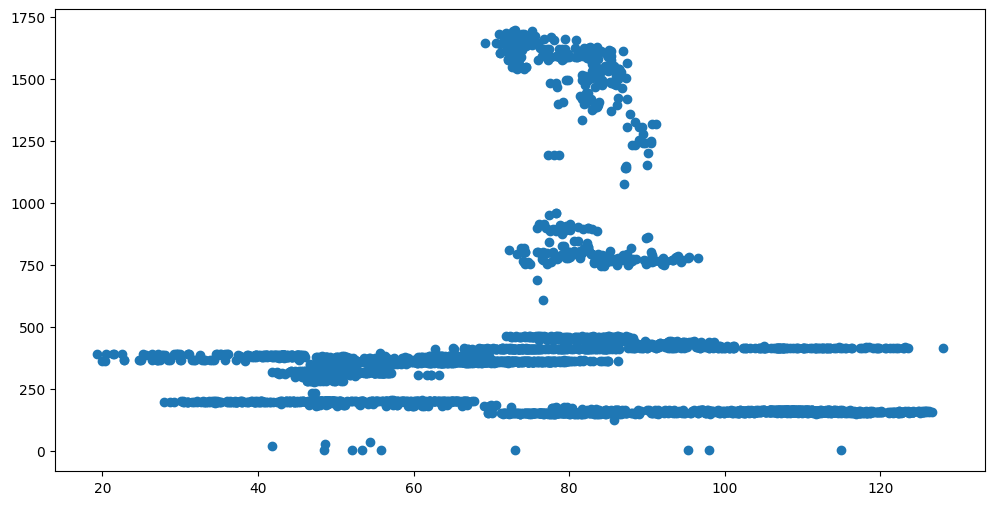

In [55]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(12, 6))
plt.scatter(
    merged_data['Brent_Close'],
    merged_data['Exchange_Close']
)

In [56]:
merged_data[['Exchange_Close', 'Brent_Close']].describe()

,Exchange_Close,Brent_Close
count,3735.000000,3735.000000
mean,374.921074,78.092011
std,333.763861,24.062937
min,1.000000,19.330000
25%,159.989998,59.154999
50%,348.000000,76.610001
75%,389.005005,100.759998
max,1696.199951,127.980003


In [57]:
merged_data['Exchange_Close'].sort_values().head(10)

Date
2015-07-29     1.0000
2011-01-25     1.5105
2011-01-26     1.5210
2011-03-17     1.5650
2016-07-12     2.8000
2017-02-15     3.1400
2018-07-20     3.5900
2017-08-08     3.6200
2016-03-22    18.0000
2016-06-28    28.0000
Name: Exchange_Close, dtype: float64

In [58]:
# How many rows have an Exchange_Close value less than 10?
bad_rows =merged_data['Exchange_Close'][merged_data['Exchange_Close'] < 100].count()
print(bad_rows)

11


During exploratory data analysis, 11 exchange rate observations were identified as inconsistent with the corresponding Open, High, and Low values. These records were investigated as potential data errors before further analysis.

In [59]:
merged_data[merged_data['Exchange_Close']<100]

,Exchange_Close,Exchange_High,Exchange_Low,Exchange_Open,Brent_Close,Brent_High,Brent_Low,Brent_Open,Brent_Volume,Exchange_Change,Brent_Range,Year
Date,,,,,,,,,,,,
2011-01-25,1.5105,152.119995,1.521000,152.119995,95.250000,95.919998,94.860001,95.919998,668,-150.609495,1.059998,2011
2011-01-26,1.5210,152.199997,149.050003,151.750000,97.910004,97.980003,96.059998,96.059998,1073,-150.229000,1.920006,2011
2011-03-17,1.5650,157.000000,154.410004,156.550003,114.900002,115.339996,110.830002,110.830002,858,-154.985003,4.509995,2011
2015-07-29,1.0000,198.850006,195.910004,195.910004,53.380001,54.320000,52.520000,53.009998,46631,-194.910004,1.799999,2015
2016-03-22,18.0000,199.000000,196.500000,196.880005,41.790001,42.119999,40.980000,41.509998,31640,-178.880005,1.139999,2016
2016-06-28,28.0000,282.000000,279.730011,280.010010,48.580002,48.759998,47.470001,47.549999,22475,-252.010010,1.289997,2016
2016-07-12,2.8000,282.000000,279.859985,279.859985,48.470001,48.560001,46.119999,46.200001,32157,-277.059985,2.440002,2016
2016-12-02,33.0000,315.000000,314.000000,315.000000,54.459999,54.500000,52.860001,53.869999,39305,-282.000000,1.639999,2016
2017-02-15,3.1400,315.000000,314.000000,315.000000,55.750000,56.250000,55.549999,55.840000,26608,-311.860000,0.700001,2017


In [60]:
cleaned_data = merged_data[merged_data['Exchange_Close'] > 100]
cleaned_data.shape

(3724, 12)

In [61]:
cleaned_data[['Exchange_Close', 'Brent_Close']].corr()

,Exchange_Close,Brent_Close
Exchange_Close,1.000000,-0.101117
Brent_Close,-0.101117,1.000000


In [62]:
cleaned_data.columns

Index(['Exchange_Close', 'Exchange_High', 'Exchange_Low', 'Exchange_Open',
       'Brent_Close', 'Brent_High', 'Brent_Low', 'Brent_Open', 'Brent_Volume',
       'Exchange_Change', 'Brent_Range', 'Year'],
      dtype='str')

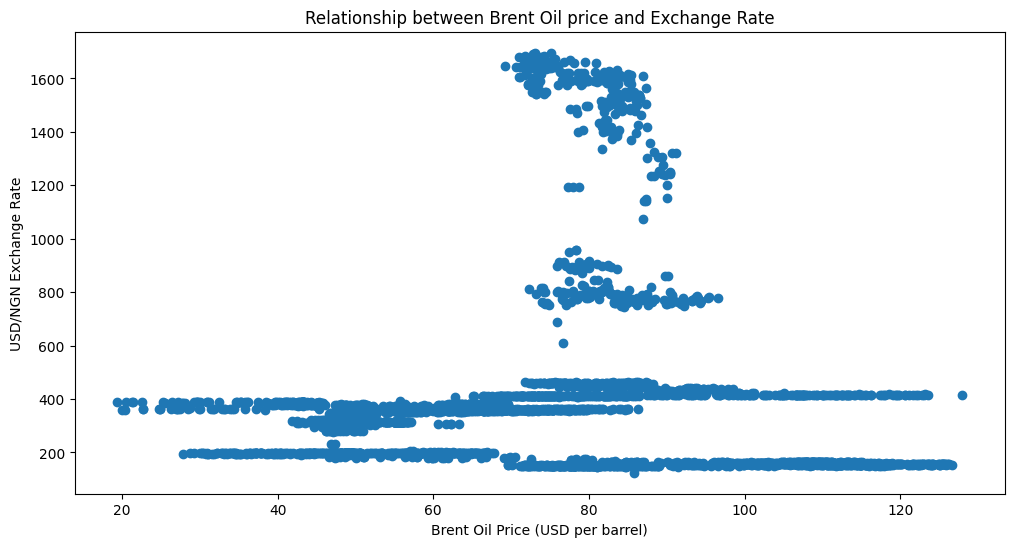

In [63]:
plt.figure(figsize=(12,6))
plt.scatter(
    cleaned_data['Brent_Close'], 
    cleaned_data['Exchange_Close']
)
plt.xlabel('Brent Oil Price (USD per barrel)')
plt.ylabel('USD/NGN Exchange Rate')
plt.title('Relationship between Brent Oil price and Exchange Rate')
plt.show()

Text(0.5, 1.0, 'Average Exchange rate from 2010 - 2024')

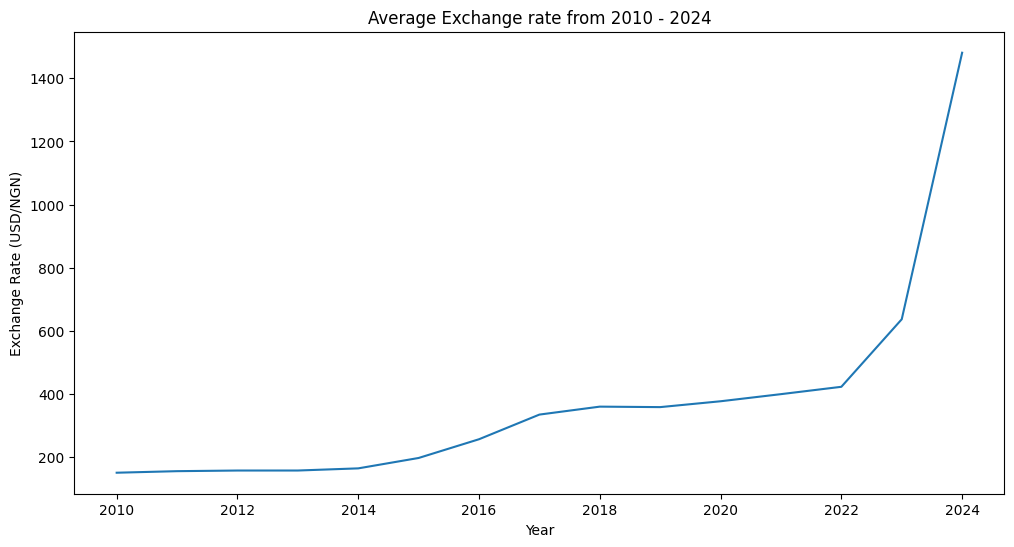

In [64]:
yearly_average = cleaned_data.groupby('Year')['Exchange_Close'].mean()
yearly_average.plot(figsize=(12,6))
plt.ylabel('Exchange Rate (USD/NGN)')
plt.xlabel('Year')
plt.title('Average Exchange rate from 2010 - 2024')

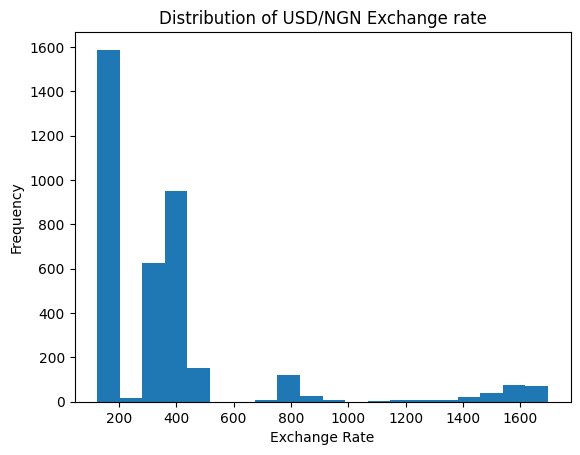

In [65]:
plt.hist(cleaned_data['Exchange_Close'], bins=20)
plt.title('Distribution of USD/NGN Exchange rate')
plt.xlabel('Exchange Rate')
plt.ylabel('Frequency')
plt.show()


The histogram indicates that the USD/NGN exchange rate is right-skewed. Most observations are concentrated at lower exchange rate values, while a relatively small number of observations occur at much higher exchange rates. This suggests that extremely high exchange rates were less common during the study period but contributed to a long right tail in the distribution.

In [66]:
# which years had average exchange rates around 150–200 and which years had averages around 350–450?

filtered_data = cleaned_data[
    (cleaned_data['Exchange_Close'] >= 150) 
    & 
    (cleaned_data['Exchange_Close'] <= 200)
]

filtered_data['Year'].value_counts()

Year
2014    250
2015    245
2012    243
2013    242
2011    230
2010    178
2016    117
Name: count, dtype: int64

In [67]:
cleaned_data['Year'].nunique()

15

In [68]:
cleaned_data.count()

Exchange_Close     3724
Exchange_High      3724
Exchange_Low       3724
Exchange_Open      3724
Brent_Close        3724
Brent_High         3724
Brent_Low          3724
Brent_Open         3724
Brent_Volume       3724
Exchange_Change    3724
Brent_Range        3724
Year               3724
dtype: int64

Text(0, 0.5, 'Exchange Rate')

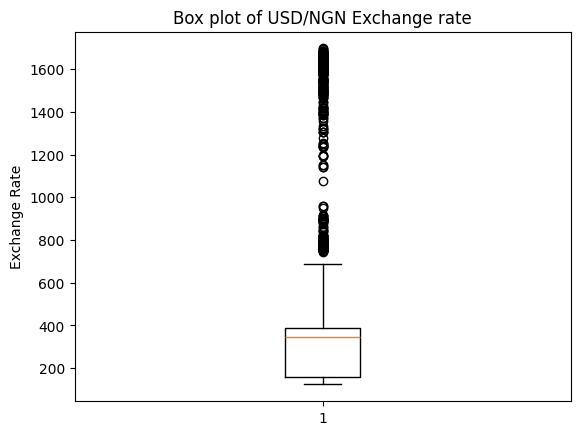

In [69]:
plt.boxplot(cleaned_data['Exchange_Close'])
plt.title('Box plot of USD/NGN Exchange rate')
plt.ylabel('Exchange Rate')

In [70]:
previous_rate = cleaned_data['Exchange_Close'].shift()

In [71]:
previous_rate.head(10)

Date
2010-01-04           NaN
2010-01-05    147.539993
2010-01-06    149.100006
2010-01-07    149.050003
2010-01-08    149.000000
2010-01-11    149.899994
2010-01-12    150.899994
2010-01-13    150.399994
2010-01-14    151.250000
2010-01-15    149.350006
Name: Exchange_Close, dtype: float64

In [72]:
cleaned_data['Exchange_Return'] = cleaned_data['Exchange_Close'].pct_change()
print(cleaned_data.head(20))

            Exchange_Close  Exchange_High  Exchange_Low  Exchange_Open  \
Date                                                                     
2010-01-04      147.539993     149.649994    147.539993     148.550003   
2010-01-05      149.100006     149.250000    147.440002     149.250000   
2010-01-06      149.050003     150.300003    146.940002     147.610001   
2010-01-07      149.000000     149.350006    146.220001     146.220001   
2010-01-08      149.899994     149.899994    147.300003     147.300003   
2010-01-11      150.899994     150.899994    148.479996     148.479996   
2010-01-12      150.399994     150.750000    148.369995     150.500000   
2010-01-13      151.250000     151.250000    148.500000     150.500000   
2010-01-14      149.350006     151.259995    149.229996     150.800003   
2010-01-15      151.100006     151.300003    149.210007     151.300003   
2010-01-19      149.740005     151.100006    149.020004     150.300003   
2010-01-20      150.199997     150.199

In [73]:
Exchange_return = cleaned_data['Exchange_Return']


<Axes: xlabel='Date'>

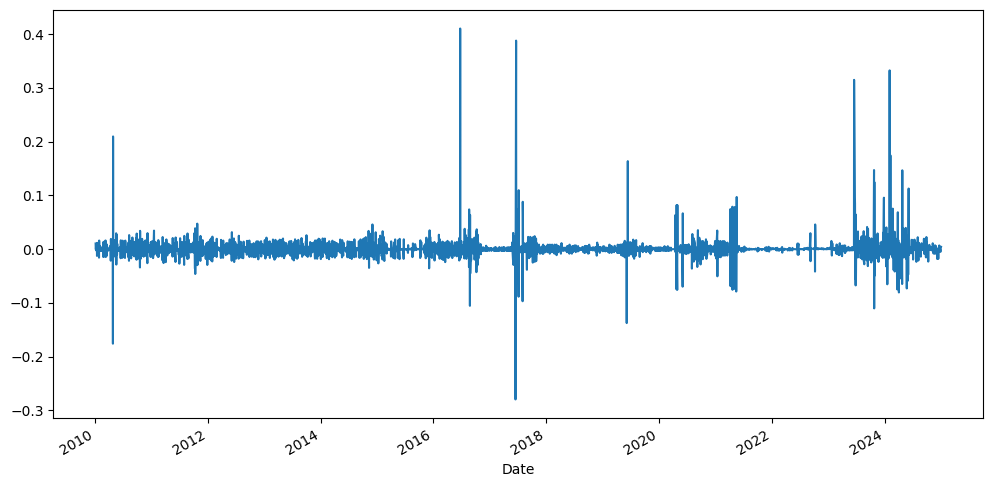

In [74]:
# How did the daily percentage change in the USD/NGN exchange rate move over time

Exchange_return.plot(figsize=(12, 6))


In [75]:
Exchange_return.std()

np.float64(0.01937961027561766)

In [76]:
# Did volatility remain the same throughout 2010–2024, or were there particular periods when the exchange rate became much more unstable?
rolling_volatility = Exchange_return.rolling(30).std()
rolling_volatility.head(35)

Date
2010-01-04         NaN
2010-01-05         NaN
2010-01-06         NaN
2010-01-07         NaN
2010-01-08         NaN
2010-01-11         NaN
2010-01-12         NaN
2010-01-13         NaN
2010-01-14         NaN
2010-01-15         NaN
2010-01-19         NaN
2010-01-20         NaN
2010-01-21         NaN
2010-01-22         NaN
2010-01-25         NaN
2010-01-26         NaN
2010-01-27         NaN
2010-01-28         NaN
2010-01-29         NaN
2010-02-01         NaN
2010-02-02         NaN
2010-02-03         NaN
2010-02-04         NaN
2010-02-05         NaN
2010-02-08         NaN
2010-02-09         NaN
2010-02-10         NaN
2010-02-11         NaN
2010-02-12         NaN
2010-02-16         NaN
2010-02-17    0.007115
2010-02-18    0.006897
2010-02-19    0.006896
2010-02-22    0.006913
2010-02-23    0.007299
Name: Exchange_Return, dtype: float64

<Axes: xlabel='Date'>

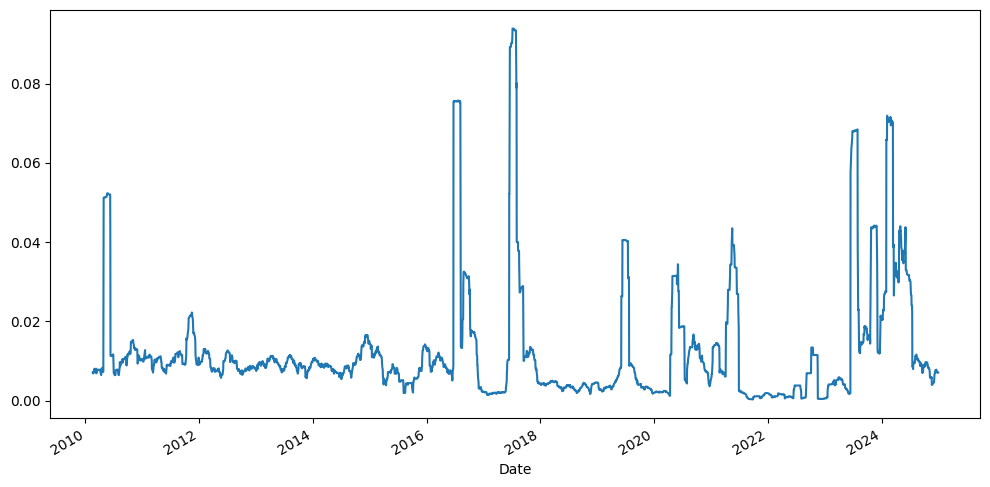

In [77]:
rolling_volatility.plot(figsize=(12, 6))

In [78]:
cleaned_data['Rolling_Volatility'] = rolling_volatility

In [79]:
cleaned_data.columns


Index(['Exchange_Close', 'Exchange_High', 'Exchange_Low', 'Exchange_Open',
       'Brent_Close', 'Brent_High', 'Brent_Low', 'Brent_Open', 'Brent_Volume',
       'Exchange_Change', 'Brent_Range', 'Year', 'Exchange_Return',
       'Rolling_Volatility'],
      dtype='str')

In [80]:
cleaned_data['Year'] = cleaned_data.index.year 

In [81]:
yearly_volatility = cleaned_data.groupby('Year')['Rolling_Volatility'].mean()
print(yearly_volatility)

Year
2010    0.015698
2011    0.011520
2012    0.009208
2013    0.009210
2014    0.009566
2015    0.007732
2016    0.020669
2017    0.019583
2018    0.003720
2019    0.008984
2020    0.011433
2021    0.010369
2022    0.003211
2023    0.020037
2024    0.025666
Name: Rolling_Volatility, dtype: float64


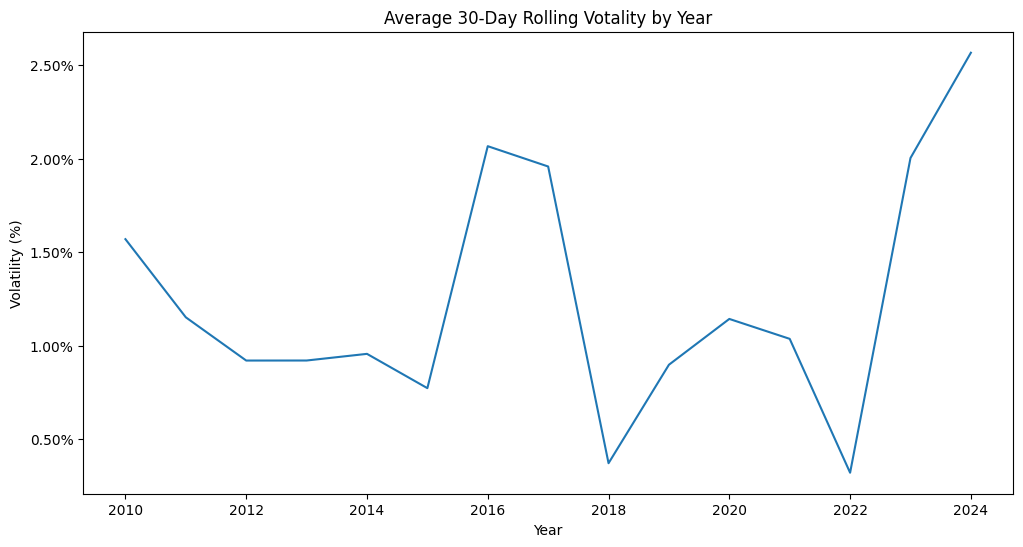

In [82]:
from matplotlib.ticker import PercentFormatter

yearly_volatility.plot(figsize=(12, 6))

plt.title('Average 30-Day Rolling Votality by Year')
plt.ylabel('Volatility (%)')
plt.xlabel('Year')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

In [83]:
cleaned_data[['Brent_Close', 'Exchange_Close']].corr()

,Brent_Close,Exchange_Close
Brent_Close,1.000000,-0.101117
Exchange_Close,-0.101117,1.000000


In [84]:
# Are daily changes in Brent oil prices related to daily changes in the USD/NGN exchange rate?

cleaned_data['Brent_Return'] = cleaned_data['Brent_Close'].pct_change()

In [85]:
cleaned_data[['Brent_Close', 'Brent_Return']].head(10)

,Brent_Close,Brent_Return
Date,,
2010-01-04,80.120003,NaN
2010-01-05,80.589996,0.005866
2010-01-06,81.889999,0.016131
2010-01-07,81.510002,-0.004640
2010-01-08,81.370003,-0.001718
2010-01-11,80.970001,-0.004916
2010-01-12,79.300003,-0.020625
2010-01-13,78.309998,-0.012484
2010-01-14,77.820000,-0.006257


In [86]:
cleaned_data[['Exchange_Return', 'Brent_Return']].corr()

,Exchange_Return,Brent_Return
Exchange_Return,1.000000,-0.011822
Brent_Return,-0.011822,1.000000


Text(0.5, 0, 'Exchange_Return')

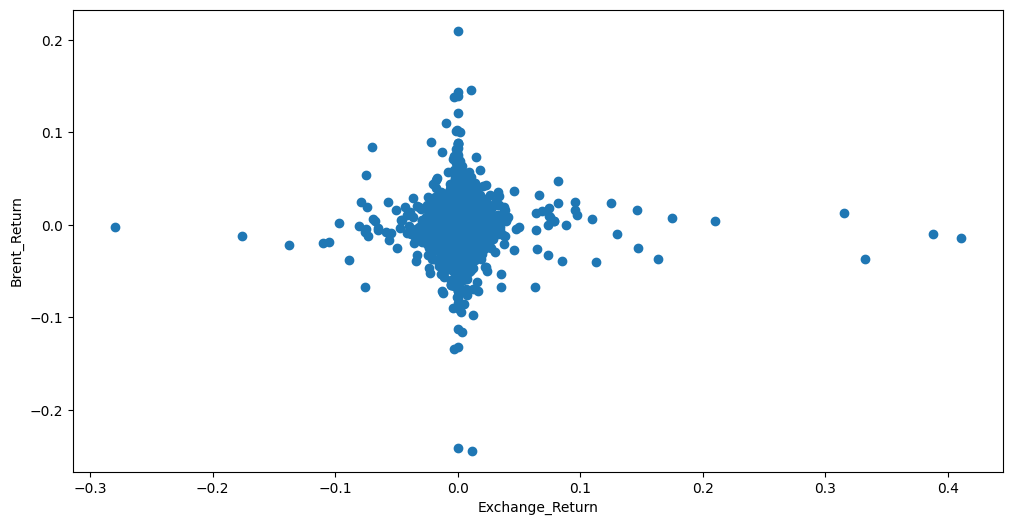

In [87]:
plt.figure(figsize=(12, 6))
plt.scatter(
    cleaned_data['Exchange_Return'],
    cleaned_data['Brent_Return']
    )
plt.ylabel('Brent_Return')
plt.xlabel('Exchange_Return')

In [88]:
# Does a change in Brent today have a relationship with an exchange-rate change a few days/weeks later

cleaned_data['Brent_Return_Lag1'] = cleaned_data['Brent_Return'].shift(1)
cleaned_data[['Brent_Return', 'Brent_Return_Lag1', 'Exchange_Return']].head(20)

,Brent_Return,Brent_Return_Lag1,Exchange_Return
Date,,,
2010-01-04,NaN,NaN,NaN
2010-01-05,0.005866,NaN,0.010573
2010-01-06,0.016131,0.005866,-0.000335
2010-01-07,-0.004640,0.016131,-0.000335
2010-01-08,-0.001718,-0.004640,0.006040
2010-01-11,-0.004916,-0.001718,0.006671
2010-01-12,-0.020625,-0.004916,-0.003313
2010-01-13,-0.012484,-0.020625,0.005652
2010-01-14,-0.006257,-0.012484,-0.012562


In [89]:
cleaned_data[['Brent_Return_Lag1', 'Exchange_Return']].corr()

# The one-day lagged correlation was slightly positive (0.009), but remained extremely close to zero, suggesting no meaningful linear relationship between the previous day's 
# Brent return and the current day's exchange-rate return.

,Brent_Return_Lag1,Exchange_Return
Brent_Return_Lag1,1.000000,0.009033
Exchange_Return,0.009033,1.000000


In [90]:
cleaned_data.columns

Index(['Exchange_Close', 'Exchange_High', 'Exchange_Low', 'Exchange_Open',
       'Brent_Close', 'Brent_High', 'Brent_Low', 'Brent_Open', 'Brent_Volume',
       'Exchange_Change', 'Brent_Range', 'Year', 'Exchange_Return',
       'Rolling_Volatility', 'Brent_Return', 'Brent_Return_Lag1'],
      dtype='str')

In [91]:
cleaned_data.to_csv("cleaned_market_data.csv")

In [92]:
cleaned_data

,Exchange_Close,Exchange_High,Exchange_Low,Exchange_Open,Brent_Close,Brent_High,Brent_Low,Brent_Open,Brent_Volume,Exchange_Change,Brent_Range,Year,Exchange_Return,Rolling_Volatility,Brent_Return,Brent_Return_Lag1
Date,,,,,,,,,,,,,,,,
2010-01-04,147.539993,149.649994,147.539993,148.550003,80.120003,79.820000,80.120003,80.120003,97,-1.010010,-0.300003,2010,NaN,NaN,NaN,NaN
2010-01-05,149.100006,149.250000,147.440002,149.250000,80.589996,80.260002,80.589996,80.589996,97,-0.149994,-0.329994,2010,0.010573,NaN,0.005866,NaN
2010-01-06,149.050003,150.300003,146.940002,147.610001,81.889999,81.699997,80.129997,81.129997,7,1.440002,1.570000,2010,-0.000335,NaN,0.016131,0.005866
2010-01-07,149.000000,149.350006,146.220001,146.220001,81.510002,81.510002,81.629997,81.510002,7,2.779999,-0.119995,2010,-0.000335,NaN,-0.004640,0.016131
2010-01-08,149.899994,149.899994,147.300003,147.300003,81.370003,81.529999,81.089996,81.370003,7,2.599991,0.440002,2010,0.006040,NaN,-0.001718,-0.004640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,1549.040039,1548.510010,1542.939941,1547.569946,72.629997,73.370003,71.980003,72.830002,20997,1.470093,1.389999,2024,-0.002595,0.007149,-0.004250,0.000823
2024-12-24,1548.510010,1548.510010,1541.430054,1548.510010,73.580002,73.809998,72.779999,72.839996,8922,0.000000,1.029999,2024,-0.000342,0.007090,0.013080,-0.004250
2024-12-26,1540.660034,1541.579956,1540.660034,1540.660034,73.260002,74.180000,72.980003,73.779999,5773,0.000000,1.199997,2024,-0.005069,0.007026,-0.004349,0.013080
